# 1. Cargar Librerias y Datasets

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import f_oneway

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn import metrics

from sklearn.model_selection import GridSearchCV

import itertools

df_demanda = pd.read_csv(r"C:\Users\Javier\Documents\Prueba DS\demanda.csv")
df_cat_prod = pd.read_csv(r"C:\Users\Javier\Documents\Prueba DS\catalogo_productos.csv")
df_demanda_test = pd.read_csv(r"C:\Users\Javier\Documents\Prueba DS\demanda_test.csv")

# 2. Análisis Exploratorio de Datos (EDA)

### Unificación de datos
Se procede a unir las bases ``df_demanda`` y ``df_cat_prod`` por la llave ``id_producto``

In [4]:
df_unida = pd.merge(df_demanda, df_cat_prod, on='id_producto', how='inner')
df_unida.head()

,date,id_producto,demanda,categoria,subcategoria,tamaño,premium,marca_exclusiva,estacional,nit_proveedor
0,2020-01-01,3,869,bebidas,Gaseosa,Pequeño,0.0,1,0,890900667.0
1,2020-01-01,4,407,congelados,Vegetales,Pequeño,0.0,1,1,890900667.0
2,2020-01-01,5,182,shampoos,Acondicionador,Pequeño,0.0,1,0,890900667.0
3,2020-01-01,6,91,bebidas,Cerveza Internacional,Pequeño,0.0,0,0,890900667.0
4,2020-01-01,7,520,panaderia_y_panificados,Otros,Pequeño,0.0,1,0,890900667.0


### Análisis de Tendencia

En julio de 2021, se abrió una tienda de la competencia a pocos metros de nuestra ubicación, lo que podría haber tenido un impacto significativo en las ventas. A partir de esta situación, se plantean las siguientes preguntas para entender cómo ha influido este cambio:

1. **¿Cuál es la estacionalidad de las ventas?, ¿la estacionalidad cambia dependiendo del producto?.**
2. **¿Cúal fué el impacto de la apertura del competidor?**
3. **¿Las ventas tienen una tendencia creciente o decreciente?**

Para responder a estas preguntas de manera efectiva, se propone agrupar las ventas por mes y/o por semana para suavizar el ruido inherente en los datos y poder observar de manera más clara la tendencia subyacente en la serie temporal de la ``demanda``. Además, se compararán las tendencias antes y después de la apertura de la tienda de la competencia, específicamente en torno al 2 de julio de 2021.

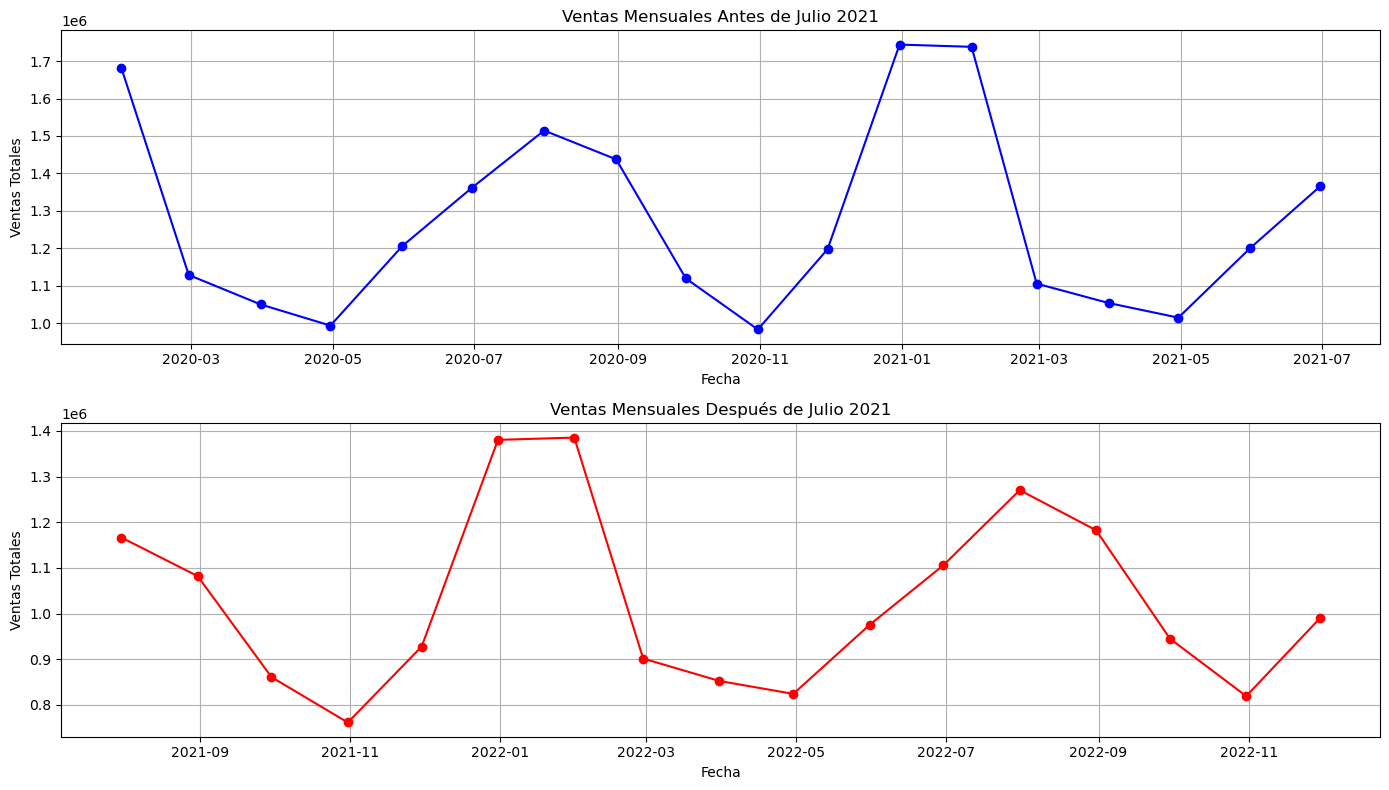

In [6]:
df_unida['date'] = pd.to_datetime(df_unida['date'])

ventas_semana = df_unida.groupby(pd.Grouper(key='date', freq='W'))['demanda'].sum().reset_index()
ventas_mes = df_unida.groupby(pd.Grouper(key='date', freq='ME'))['demanda'].sum().reset_index()

# Definir la fecha de corte
fecha_corte = '2021-07-02'

# Filtrar datos antes y después de la fecha de corte
ventas_antes = ventas_mes[ventas_mes['date'] < fecha_corte]
ventas_despues = ventas_mes[ventas_mes['date'] >= fecha_corte]

# Crear una figura para los gráficos
plt.figure(figsize=(14, 8))

# Graficar las ventas antes de la fecha de corte
plt.subplot(2, 1, 1)  # Gráfico 1 (en la parte superior)
plt.plot(ventas_antes['date'], ventas_antes['demanda'], marker='o', color='b')
plt.title('Ventas Mensuales Antes de Julio 2021')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.grid(True)

# Graficar las ventas después de la fecha de corte
plt.subplot(2, 1, 2)  # Gráfico 2 (en la parte inferior)
plt.plot(ventas_despues['date'], ventas_despues['demanda'], marker='o', color='r')
plt.title('Ventas Mensuales Después de Julio 2021')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.grid(True)

# Ajustar el espacio entre los gráficos
plt.tight_layout()

# Mostrar los gráficos
plt.show()

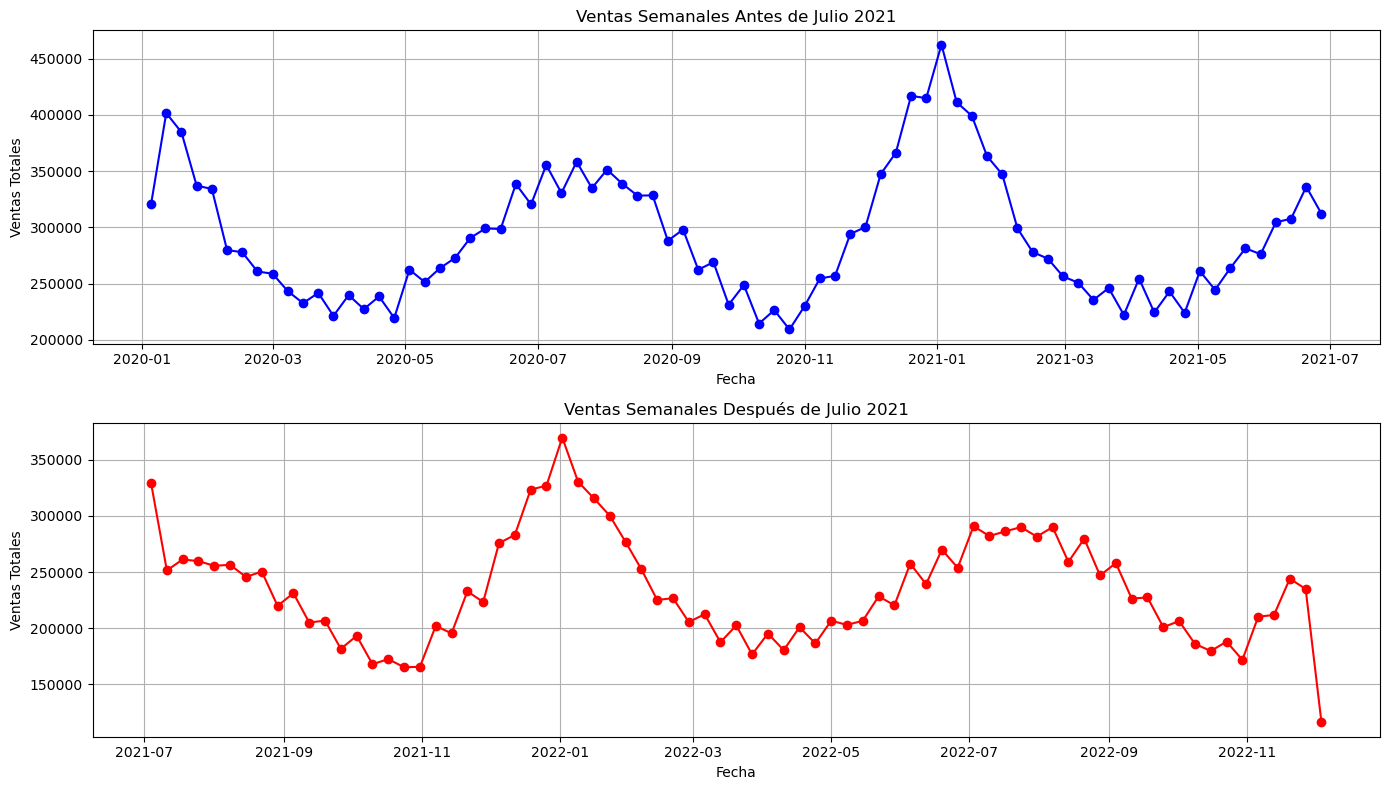

In [138]:
ventas_Sem_antes = ventas_semana[ventas_semana['date'] < fecha_corte]
ventas_Sem_despues = ventas_semana[ventas_semana['date'] >= fecha_corte]

# Crear una figura para los gráficos
plt.figure(figsize=(14, 8))

# Graficar las ventas antes de la fecha de corte
plt.subplot(2, 1, 1)  # Gráfico 1 (en la parte superior)
plt.plot(ventas_Sem_antes['date'], ventas_Sem_antes['demanda'], marker='o', color='b')
plt.title('Ventas Semanales Antes de Julio 2021')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.grid(True)

# Graficar las ventas después de la fecha de corte
plt.subplot(2, 1, 2)  # Gráfico 2 (en la parte inferior)
plt.plot(ventas_Sem_despues['date'], ventas_Sem_despues['demanda'], marker='o', color='r')
plt.title('Ventas Semanales Después de Julio 2021')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.grid(True)

# Ajustar el espacio entre los gráficos
plt.tight_layout()

# Mostrar los gráficos
plt.show()

Al comparar ambas series (mensual y semanal), se observa un patrón similar en ambas, donde al inicio de cada año se presenta un pico o aumento significativo en la demanda, seguido por una disminución que perdura hasta mayo. Después de ese periodo, las ventas vuelven a experimentar un incremento. Este comportamiento sugiere una posible estacionalidad anual en la demanda.

Para comprender mejor la tendencia subyacente de la serie, el impacto de la apertura del competidor y si la estacionalidad cambia dependiendo del producto, se continuará con el análisis a nivel semanal. El análisis semanal permitirá detectar fluctuaciones más finas y cambios en la dinámica de la demanda, tanto antes como después de la apertura de la tienda competidora, proporcionando una visión más detallada y precisa de cómo estos factores afectan las ventas.

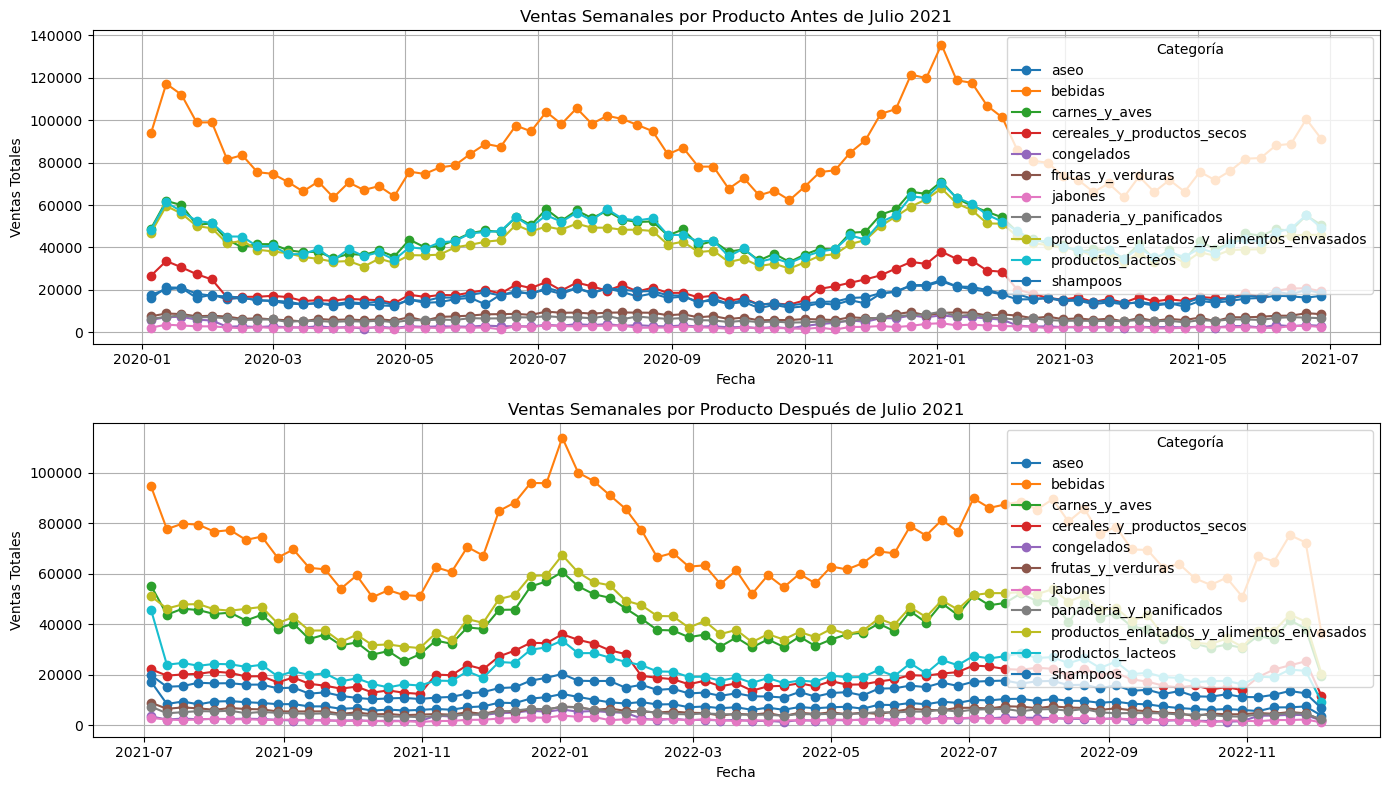

In [151]:
ventas_semanaXprod = df_unida.groupby([pd.Grouper(key='date', freq='W'), 'categoria'])['demanda'].sum().reset_index()

ventas_semanaXprod.set_index(['date', 'categoria'], inplace=True)

# Dividir los datos antes y después de la fecha de corte
ventas_Sem_antes2 = ventas_semanaXprod[ventas_semanaXprod.index.get_level_values('date') < fecha_corte]
ventas_Sem_despues2 = ventas_semanaXprod[ventas_semanaXprod.index.get_level_values('date') >= fecha_corte]

# Crear una figura para los gráficos
plt.figure(figsize=(14, 8))

# Graficar las ventas antes de la fecha de corte
plt.subplot(2, 1, 1)  # Gráfico 1 (en la parte superior)
# Iterar sobre las categorías antes de la fecha de corte
for categoria in ventas_Sem_antes2.index.get_level_values('categoria').unique():
    ventas_categoria = ventas_Sem_antes2.xs(categoria, level='categoria')
    plt.plot(ventas_categoria.index.get_level_values('date'), ventas_categoria.values, marker='o', label=categoria)

# Personalizar el gráfico de ventas antes de la apertura
plt.title('Ventas Semanales por Producto Antes de Julio 2021')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.legend(title='Categoría')
plt.grid(True)

# Graficar las ventas después de la fecha de corte
plt.subplot(2, 1, 2)  # Gráfico 2 (en la parte inferior)
# Iterar sobre las categorías después de la fecha de corte
for categoria in ventas_Sem_despues2.index.get_level_values('categoria').unique():
    ventas_categoria = ventas_Sem_despues2.xs(categoria, level='categoria')
    plt.plot(ventas_categoria.index.get_level_values('date'), ventas_categoria.values, marker='o', label=categoria)

# Personalizar el gráfico de ventas después de la apertura
plt.title('Ventas Semanales por Producto Después de Julio 2021')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.legend(title='Categoría')
plt.grid(True)

# Ajustar el espacio entre los gráficos
plt.tight_layout()

# Mostrar los gráficos
plt.show()

Al observar los patrones de ventas semanales antes y después de la apertura de la tienda de la competencia en el gráfico anterior, podemos notar que las tendencias de los productos siguen un comportamiento similar. Específicamente, todos los productos presentan un pico de ventas a principios de año (enero), seguido de una disminución en los meses posteriores, con un repunte nuevamente en la mitad del año.

Este comportamiento uniforme sugiere que la estacionalidad de las ventas no cambia significativamente dependiendo del producto. Los picos estacionales parecen ser consistentes para todas las categorías, indicando que factores como las temporadas del año tienen un impacto común en las ventas, independientemente del tipo de producto. Esto podría implicar que las fluctuaciones estacionales no están directamente influenciadas por la competencia, sino por factores más amplios como festividades, clima, o comportamientos de consumo generalizados.

A pesar de la apertura de la tienda competidora en julio de 2021, los productos no muestran una alteración clara en su estacionalidad, lo que sugiere que la variabilidad estacional sigue siendo un factor dominante en las ventas, independientemente de la competencia cercana.

In [153]:
ventas_semana2 = df_unida.groupby(pd.Grouper(key='date', freq='W'))['demanda'].sum().reset_index()

# Asegúrate de que el índice sea datetime
ventas_semana2.index = pd.to_datetime(ventas_semana2.index, errors='coerce')

# Calcular la media móvil de 4 semanas
ventas_semana2['media_movil'] = ventas_semana2['demanda'].rolling(window=4).mean()

# Eliminar valores NaN de la columna 'media_movil' para evitar problemas con la regresión
ventas_semana2 = ventas_semana2.dropna(subset=['media_movil'])

# Dividir los datos en dos partes: antes y después de la fecha de corte
fecha_corte = '2021-07-02'
fecha_corte = pd.to_datetime(fecha_corte)

ventas_Sem_antes2 = ventas_semana2[ventas_semana2['date'] < fecha_corte]
ventas_Sem_despues2 = ventas_semana2[ventas_semana2['date'] >= fecha_corte]

# Función para calcular la pendiente de la regresión lineal
def calcular_pendiente(series):
    # Crear el índice numérico para la regresión
    X = np.arange(len(series)).reshape(-1, 1)
    y = series.values

    # Ajustar el modelo de regresión lineal
    model = LinearRegression()
    model.fit(X, y)

    # Retornar la pendiente (coeficiente)
    return model.coef_[0]

# Calcular la pendiente de la media móvil antes de la fecha de corte
pendiente_antes = calcular_pendiente(ventas_Sem_antes2['media_movil'])

# Calcular la pendiente de la media móvil después de la fecha de corte
pendiente_despues = calcular_pendiente(ventas_Sem_despues2['media_movil'])

# Imprimir las pendientes
print(f'Pendiente de la media móvil antes de Julio 2021: {pendiente_antes}')
print(f'Pendiente de la media móvil después de Julio 2021: {pendiente_despues}')

Pendiente de la media móvil antes de Julio 2021: 17.76690611664307
Pendiente de la media móvil después de Julio 2021: -341.3789900426742


In [155]:
pendiente_antes2 = calcular_pendiente(ventas_Sem_antes2['demanda'])
pendiente_despues2 = calcular_pendiente(ventas_Sem_despues2['demanda'])
print(f'Pendiente de la demanda antes de Julio 2021: {pendiente_antes2}')
print(f'Pendiente de la demanda después de Julio 2021: {pendiente_despues2}')

Pendiente de la demanda antes de Julio 2021: 209.42401137980087
Pendiente de la demanda después de Julio 2021: -305.0102418207681


Para analizar la tendencia de la serie temporal, se propone realizar una regresión lineal tanto sobre los datos de ``demanda`` como sobre **la media móvil de las últimas 4 semanas**. Al evaluar las pendientes de las regresiones antes y después de la apertura de la tienda competidora en julio de 2021, se observan patrones claros:

1. **Antes de la apertura** de la tienda competidora, tanto la regresión de la demanda como la de la media móvil muestran **pendientes positivas**, lo que indica que la tendencia de las ventas era creciente. Esto sugiere que, en este periodo, las ventas estaban experimentando un crecimiento constante.

2. **Después de la apertura** de la tienda competidora, las pendientes de ambas regresiones se vuelven negativas, lo que implica una **tendencia decreciente** en las ventas. Este cambio en la pendiente refleja una disminución en la demanda tras la apertura de la competencia.

Los resultados de las regresiones y los valores de las pendientes confirman que **la apertura de la tienda competidora tuvo un impacto negativo** en las ventas. La tendencia de crecimiento se invirtió, y las ventas comenzaron a disminuir a partir de la fecha mencionada, sugiriendo que la competencia cercana afectó el rendimiento de las ventas de manera significativa.

### Análisis de datos
Para buscar correlación con mi variable a predecir ``demanda`` frente a mis covariables, se utilizarán boxplots como herramienta visual para explorar y comprender la distribución de los datos, lo que permiten observar la diferencia de medias entre las distintas categorías de las covariables, identificación de outliers o valores atípicos que pueden influir en el comportamiento de los datos. Este análisis visual se complementará con pruebas estadísticas adicionales, como ANOVA o correlaciones, para confirmar si las diferencias observadas entre las medias son estadísticamente significativas y, en última instancia, determinar qué variables son relevantes para predecir la demanda de manera más precisa.

C:\Users\Javier\AppData\Local\Temp\ipykernel_6128\4182246630.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




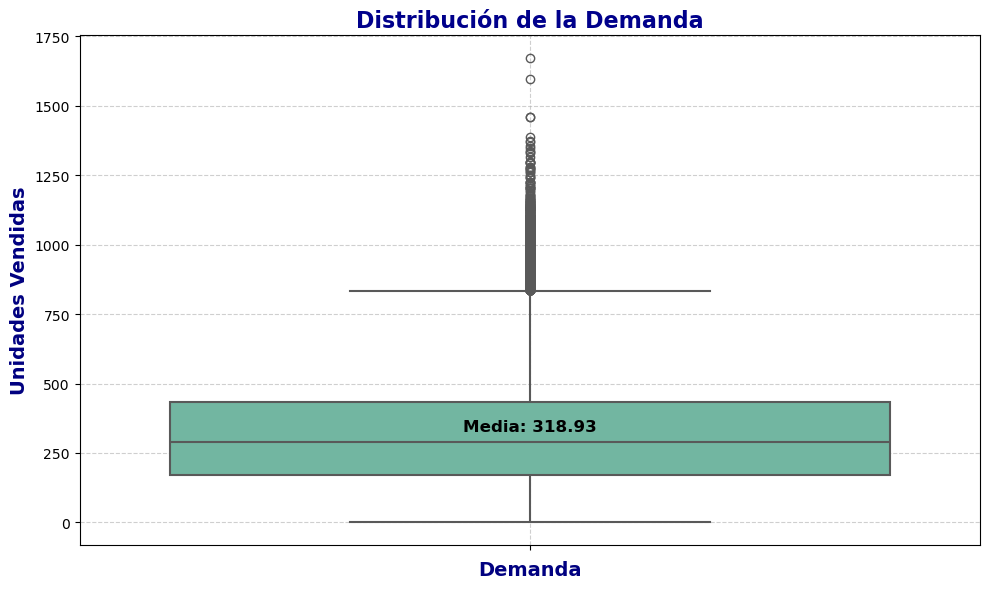

In [270]:
# Configurar los gráficos y paletas de colores
plt.figure(figsize=(10, 6))

# Boxplot para la distribución de la demanda
ax = sns.boxplot(y='demanda', data=df_unida, palette='Set2', linewidth=1.5)

# Calcular la media de la columna 'demanda'
mean_value = df_unida['demanda'].mean()

# Anotar la media en el gráfico
plt.text(0, mean_value, f'Media: {mean_value:.2f}', horizontalalignment='center', fontsize=12, color='black', weight='bold', verticalalignment='bottom')

# Títulos y etiquetas
plt.title('Distribución de la Demanda', fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel('Demanda', fontsize=14, fontweight='bold', color='navy')
plt.ylabel('Unidades Vendidas', fontsize=14, fontweight='bold', color='navy')

# Mejorar la visibilidad de las etiquetas del eje X
plt.xticks(rotation=45, ha='right', fontsize=12)

# Mejorar la visualización de la rejilla (grid)
plt.grid(True, linestyle='--', alpha=0.6)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

El boxplot general muestra que existe una variabilidad considerable en la demanda, con varios outliers que indican productos con demandas significativamente más altas que el resto. Esto sugiere que algunos productos podrían tener un comportamiento excepcional en términos de ventas, lo que podría estar relacionado con factores como promociones, tendencias de mercado o estacionalidad.

C:\Users\Javier\AppData\Local\Temp\ipykernel_6128\208715016.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




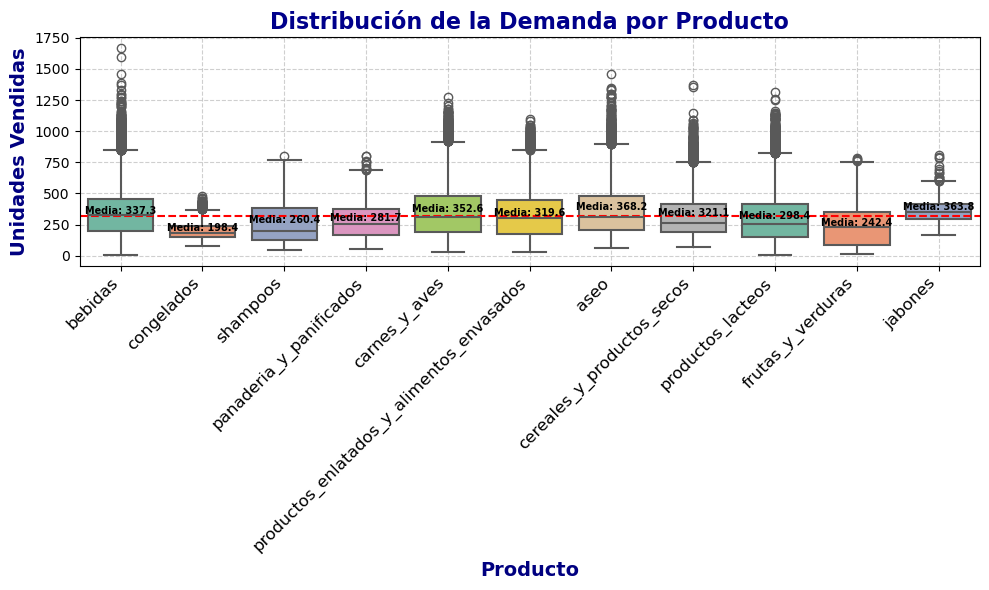

In [272]:
plt.figure(figsize=(10, 6))

# Boxplot
ax = sns.boxplot(x='categoria', y='demanda', data=df_unida, palette='Set2', linewidth=1.5)

# Agregar la mediana global
plt.axhline(318.93, color='red', linestyle='--')

# Títulos y etiquetas
plt.title('Distribución de la Demanda por Producto', fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel('Producto', fontsize=14, fontweight='bold', color='navy')
plt.ylabel('Unidades Vendidas', fontsize=14, fontweight='bold', color='navy')

# Anotar los cuartiles y media en el boxplot
for i in range(len(df_unida['categoria'].unique())):
    # Coordenadas del gráfico
    median_value = df_unida[df_unida['categoria'] == df_unida['categoria'].unique()[i]]['demanda'].mean()
    plt.text(i, median_value, f'Media: {median_value:.1f}', horizontalalignment='center', fontsize=7, color='black', weight='bold')

# Mejorar la visibilidad de las etiquetas del eje X
plt.xticks(rotation=45, ha='right', fontsize=12)

# Mejorar la visualización de la rejilla (grid)
plt.grid(True, linestyle='--', alpha=0.6)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

Esta gráfica muestra la distribución de la demanda para cada una de los productos. El boxplot representa la mediana, los cuartiles y los outliers de la demanda.

- **Aseo** presenta la media de demanda más alta, indicando que este producto tiene un consumo constante o más elevado en comparación con otros. Por otro lado, **Congelados** tiene la demanda más baja, lo que podría estar relacionado con factores estacionales o la naturaleza del producto.
- Se observan **outliers** en varias categorías, lo que indica que ciertos productos dentro de estas categorías tienen picos de demanda atípicos. Es relevante identificar estos productos, ya que pueden ser de interés para estrategias de marketing o ajustes en la oferta.
- Los productos de **Shampoo** y **Frutas y Verduras** presentan menos outliers, lo que sugiere una demanda más homogénea y predecible para estos productos.
- La **línea roja punteada** que representa la media global de la demanda (318 unidades vendidas) permite observar cómo cada categoría se posiciona en relación con el promedio general. Se observa que varios productos tienen una demanda superior a la media global, lo que podría indicar su éxito en el mercado.

In [67]:
categoria_groups = [df_unida[df_unida['categoria'] == cat]['demanda'] for cat in df_unida['categoria'].unique()]
f_stat, p_value = f_oneway(*categoria_groups)
print(f'ANOVA p-value: {p_value}')

ANOVA p-value: 0.0


Con un *p-value* igual 0.0 de la prueba **ANOVA** se confirma que hay diferencia estadísticamente significativa en las medias de al menos 2 de las categorias.

C:\Users\Javier\AppData\Local\Temp\ipykernel_6128\3020568903.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


posx and posy should be finite values
posx and posy should be finite values


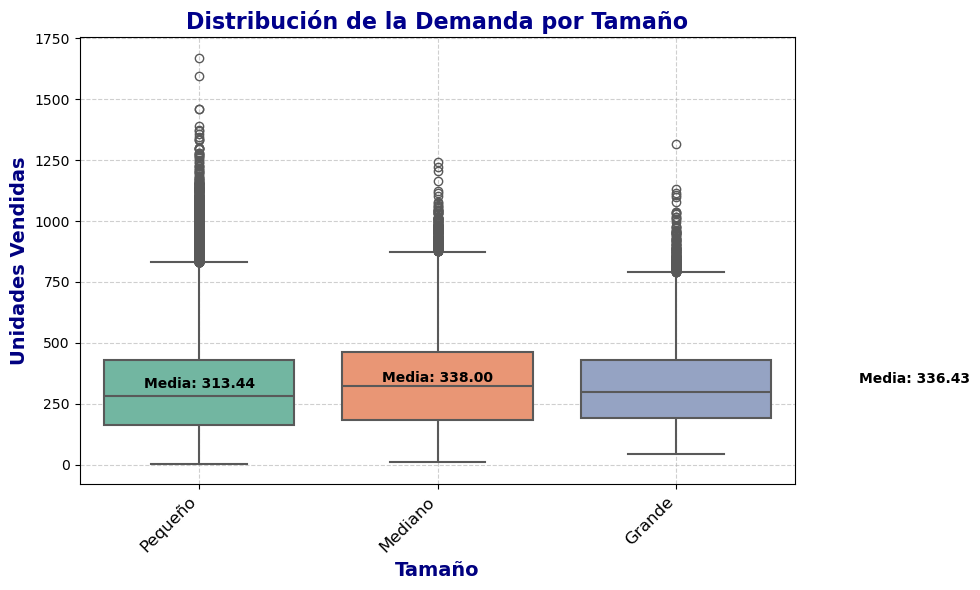

In [274]:
plt.figure(figsize=(10, 6))

# Boxplot
ax = sns.boxplot(x='tamaño', y='demanda', data=df_unida, palette='Set2', linewidth=1.5)

# Títulos y etiquetas
plt.title('Distribución de la Demanda por Tamaño', fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel('Tamaño', fontsize=14, fontweight='bold', color='navy')
plt.ylabel('Unidades Vendidas', fontsize=14, fontweight='bold', color='navy')

# Anotar los cuartiles y media en el boxplot
for i in range(len(df_unida['tamaño'].unique())):
    # Coordenadas del gráfico
    median_value = df_unida[df_unida['tamaño'] == df_unida['tamaño'].unique()[i]]['demanda'].mean()
    plt.text(i, median_value, f'Media: {median_value:.2f}', horizontalalignment='center', fontsize=10, color='black', weight='bold')

# Mejorar la visibilidad de las etiquetas del eje X
plt.xticks(rotation=45, ha='right', fontsize=12)

# Mejorar la visualización de la rejilla (grid)
plt.grid(True, linestyle='--', alpha=0.6)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

Al analizar la demanda en función del **tamaño** de los productos, no se observan grandes diferencias en la distribución ni en la media entre los diferentes tamaños, lo que sugiere que el tamaño no tiene un impacto significativo en la variabilidad de la demanda.

In [70]:
##debido a que la variable trae datos faltantes toca realizar un filtro eilimando estos datos faltantes para poder correr el test de ANOVA

df_tam = df_unida.dropna(subset=['tamaño'])

tamaño_groups = [df_tam[df_tam['tamaño'] == cat]['demanda'] for cat in df_tam['tamaño'].unique()]
f_stat, p_value = f_oneway(*tamaño_groups)
print(f'ANOVA p-value: {p_value}')

ANOVA p-value: 1.5371861116367038e-67


Con un *p-value* menor a 0.01 de la prueba **ANOVA** se confirma que hay diferencia estadísticamente significativa en las medias de al menos 2 de los tamaños.

C:\Users\Javier\AppData\Local\Temp\ipykernel_6128\612606119.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


posx and posy should be finite values
posx and posy should be finite values


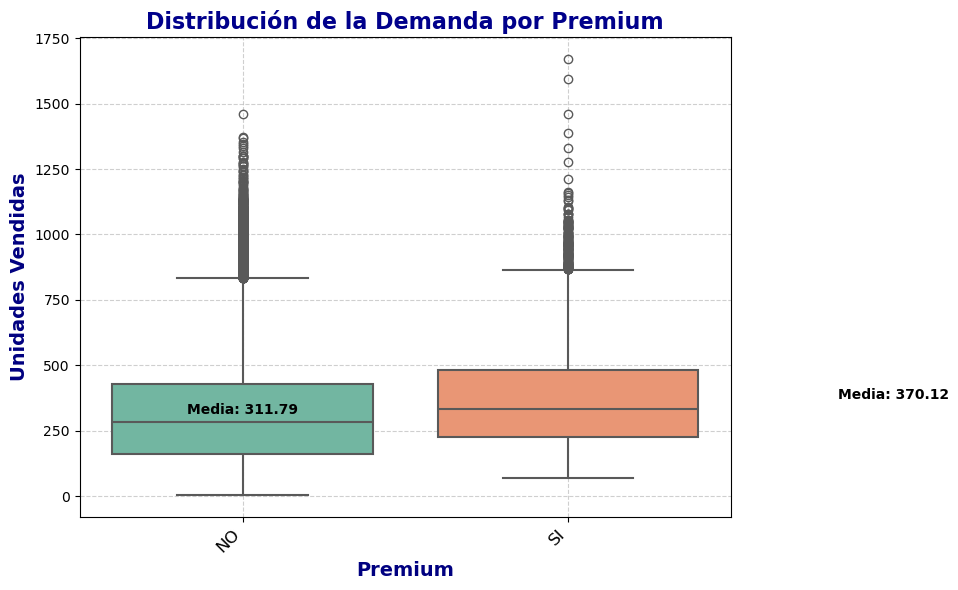

In [276]:
plt.figure(figsize=(10, 6))

# Boxplot
ax = sns.boxplot(x='premium', y='demanda', data=df_unida, palette='Set2', linewidth=1.5)

# Cambiar valores del eje X de 0 y 1 a SI y NO
plt.xticks(ticks=[0, 1], labels=['NO', 'SI'], fontsize=12)

# Añadir etiquetas y título
plt.title('Distribución de la Demanda por Premium', fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel('Premium', fontsize=14, fontweight='bold', color='navy')
plt.ylabel('Unidades Vendidas', fontsize=14, fontweight='bold', color='navy')

# Anotar los cuartiles y media en el boxplot
for i in range(len(df_unida['premium'].unique())):
    # Coordenadas del gráfico
    median_value = df_unida[df_unida['premium'] == df_unida['premium'].unique()[i]]['demanda'].mean()
    plt.text(i, median_value, f'Media: {median_value:.2f}', horizontalalignment='center', fontsize=10, color='black', weight='bold')
    
# Mejorar la visibilidad de las etiquetas del eje X
plt.xticks(rotation=45, ha='right', fontsize=12)

# Mejorar la visualización de la rejilla (grid)
plt.grid(True, linestyle='--', alpha=0.6)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

Productos **Premium** y **No Premium** muestran una distribución y media similares en sus demandas, lo que indica que no hay una diferencia sustancial en la demanda de estos dos grupos. Esto podría sugerir que los consumidores no perciben una diferencia significativa en términos de valor o calidad entre ambos grupos.

In [73]:
##debido a que la variable trae datos faltantes toca realizar un filtro eilimando estos datos faltantes para poder correr el test de ANOVA

df_prem = df_unida.dropna(subset=['premium'])

premium_groups = [df_prem[df_prem['premium'] == cat]['demanda'] for cat in df_prem['premium'].unique()]
f_stat, p_value = f_oneway(*premium_groups)
print(f'ANOVA p-value: {p_value}')

ANOVA p-value: 8.646192860362201e-182


Con un *p-value* menor a 0.01 de la prueba **ANOVA** se confirma que hay diferencia estadísticamente significativa en las medias de la variable premium.

C:\Users\Javier\AppData\Local\Temp\ipykernel_6128\2055030078.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




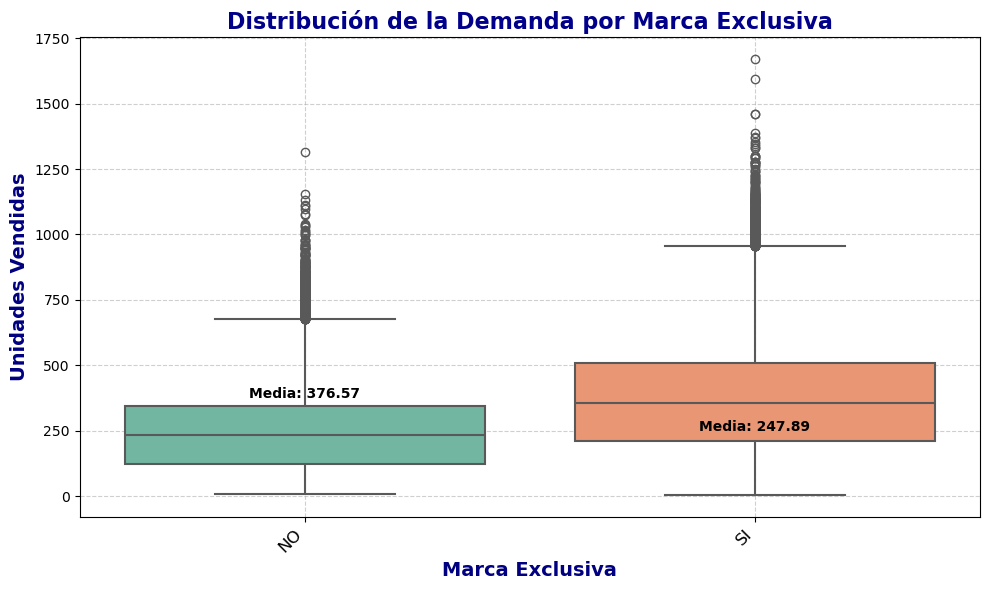

In [278]:
plt.figure(figsize=(10, 6))

# Boxplot
ax = sns.boxplot(x='marca_exclusiva', y='demanda', data=df_unida, palette='Set2', linewidth=1.5)

# Cambiar valores del eje X de 0 y 1 a SI y NO
plt.xticks(ticks=[0, 1], labels=['NO', 'SI'], fontsize=12)

# Añadir etiquetas y título
plt.title('Distribución de la Demanda por Marca Exclusiva', fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel('Marca Exclusiva', fontsize=14, fontweight='bold', color='navy')
plt.ylabel('Unidades Vendidas', fontsize=14, fontweight='bold', color='navy')

# Anotar los cuartiles y media en el boxplot
for i in range(len(df_unida['marca_exclusiva'].unique())):
    # Coordenadas del gráfico
    median_value = df_unida[df_unida['marca_exclusiva'] == df_unida['marca_exclusiva'].unique()[i]]['demanda'].mean()
    plt.text(i, median_value, f'Media: {median_value:.2f}', horizontalalignment='center', fontsize=10, color='black', weight='bold')
    
# Mejorar la visibilidad de las etiquetas del eje X
plt.xticks(rotation=45, ha='right', fontsize=12)

# Mejorar la visualización de la rejilla (grid)
plt.grid(True, linestyle='--', alpha=0.6)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

En cuanto a la **marca exclusiva**, se observa una diferencia notable en la distribución y la media entre productos de marca exclusiva y no exclusiva. Esto sugiere que los productos con marca exclusiva tienen un comportamiento de demanda distinto, posiblemente debido a su diferenciación en el mercado.

In [76]:
marca_groups = [df_unida[df_unida['marca_exclusiva'] == cat]['demanda'] for cat in df_unida['marca_exclusiva'].unique()]
f_stat, p_value = f_oneway(*marca_groups)
print(f'ANOVA p-value: {p_value}')

ANOVA p-value: 0.0


Con un *p-value* menor a 0.01 de la prueba **ANOVA** se confirma que hay diferencia estadísticamente significativa en las medias de la variable Marca exclusiva.

C:\Users\Javier\AppData\Local\Temp\ipykernel_6128\2912924465.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




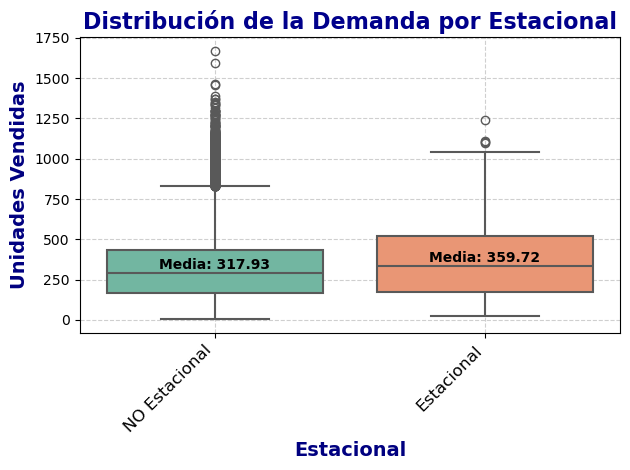

In [280]:
# Boxplot
ax = sns.boxplot(x='estacional', y='demanda', data=df_unida, palette='Set2', linewidth=1.5)

# Cambiar valores del eje X de 0 y 1 a SI y NO
plt.xticks(ticks=[0, 1], labels=['NO Estacional', 'Estacional'], fontsize=12)

# Títulos y etiquetas
plt.title('Distribución de la Demanda por Estacional', fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel('Estacional', fontsize=14, fontweight='bold', color='navy')
plt.ylabel('Unidades Vendidas', fontsize=14, fontweight='bold', color='navy')

# Anotar los cuartiles y media en el boxplot
for i in range(len(df_unida['estacional'].unique())):
    # Coordenadas del gráfico
    median_value = df_unida[df_unida['estacional'] == df_unida['estacional'].unique()[i]]['demanda'].mean()
    plt.text(i, median_value, f'Media: {median_value:.2f}', horizontalalignment='center', fontsize=10, color='black', weight='bold')

# Mejorar la visibilidad de las etiquetas del eje X
plt.xticks(rotation=45, ha='right', fontsize=12)

# Mejorar la visualización de la rejilla (grid)
plt.grid(True, linestyle='--', alpha=0.6)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

La variable **estacional** muestra que no hay una gran diferencia en las medias de los productos estacionales y no estacionales, pero la distribución es más dispersa en los productos no estacionales. Además, los productos estacionales presentan menos outliers, lo que podría indicar que su demanda es más predecible y menos influenciada por factores atípicos.

In [79]:
estacional_groups = [df_unida[df_unida['estacional'] == cat]['demanda'] for cat in df_unida['estacional'].unique()]
f_stat, p_value = f_oneway(*estacional_groups)
print(f'ANOVA p-value: {p_value}')

ANOVA p-value: 7.670309770327245e-31


Con un *p-value* menor a 0.01 de la prueba **ANOVA** se confirma que hay diferencia estadísticamente significativa en las medias de la variable Estacional.

En resumen, los boxplots y el análisis de la media han proporcionado una visión clara sobre las variabilidades y tendencias de la demanda. Las diferencias significativas entre categorías, productos premium y no premium, y las variaciones estacionales destacan factores clave que pueden influir en la estrategia de ventas y marketing. Además, la prueba ANOVA refuerza la existencia de diferencias significativas, lo que abre la puerta a decisiones más informadas en cuanto a la gestión de inventarios, promociones y posicionamiento de productos en el mercado.

# 3. Preprocesamiento de Datos

### Limpieza de datos

In [294]:
print(df_unida.isna().sum())
print(f"Total de datos: {df_unida.shape[0]}")

date                   0
id_producto            0
demanda                0
categoria              0
subcategoria       30032
tamaño              2241
premium             4277
marca_exclusiva        0
estacional             0
nit_proveedor       1028
dtype: int64
Total de datos: 126460


Las variables ``tamaño`` y ``premium`` presentan datos faltantes en alrededor del 3% de las filas de la base de datos. Aunque este porcentaje no es extremadamente alto, es importante evitar la pérdida de esta información crucial, ya que estas variables pueden tener un impacto significativo en la predicción del modelo. Revisando los datos se podria imputar el tamaño con un conocimiento empirico o por la moda, pero no se recomienda imputar estos valores faltantes ya que podría introducir sesgos o no reflejar el comportamiento real de los datos, por eso se propone una alternativa que es crear una variable indicadora que marque las filas con datos faltantes. De esta manera, en lugar de eliminar las filas con valores faltantes o imputarlos de manera arbitraria, esta nueva variable indicadora permitirá que el modelo reconozca que estos valores son faltantes y los trate como una categoría especial. Es posible que los valores faltantes en ``tamaño`` y ``premium`` tengan un significado implícito o estén relacionados con características específicas de ciertos productos o de su naturaleza de venta, lo que sugiere que su ausencia podría ser relevante para la predicción.

In [8]:
#df_cat_prod[df_cat_prod['subcategoria'].isin(['Pavo', 'Yogur', 'Cerveza Internacional'])].sort_values(by='subcategoria')
df_unida=pd.get_dummies(df_unida, columns=['categoria'], dummy_na=False,dtype=int)
df_unida=pd.get_dummies(df_unida, columns=['tamaño'], dummy_na=True,dtype=int)
df_unida=pd.get_dummies(df_unida, columns=['premium'], dummy_na=True,dtype=int)
df_unida.head()

,date,id_producto,demanda,subcategoria,marca_exclusiva,estacional,nit_proveedor,categoria_aseo,categoria_bebidas,categoria_carnes_y_aves,...,categoria_productos_enlatados_y_alimentos_envasados,categoria_productos_lacteos,categoria_shampoos,tamaño_Grande,tamaño_Mediano,tamaño_Pequeño,tamaño_nan,premium_0.0,premium_1.0,premium_nan
0,2020-01-01,3,869,Gaseosa,1,0,890900667.0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,2020-01-01,4,407,Vegetales,1,1,890900667.0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
2,2020-01-01,5,182,Acondicionador,1,0,890900667.0,0,0,0,...,0,0,1,0,0,1,0,1,0,0
3,2020-01-01,6,91,Cerveza Internacional,0,0,890900667.0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
4,2020-01-01,7,520,Otros,1,0,890900667.0,0,0,0,...,0,0,0,0,0,1,0,1,0,0


En el análisis previo se encontraron outliers en la variable demanda, los cuales podrían explicarse por factores estacionales o eventos específicos dentro del ciclo de consumo, como aumentos en la demanda durante ciertos períodos del año (por la pandemia tambien). Estos outliers no necesariamente son errores o datos inválidos, sino que reflejan patrones naturales en los datos que están asociados a la estacionalidad, por ejemplo, durante las festividades o temporadas altas de ventas. Dado que la estacionalidad puede ser un factor importante en el comportamiento de la demanda, no se aplicará ninguna transformación a la variable demanda en este momento.

En lugar de eso, se optará por evaluar el impacto de estos outliers al aplicar el modelo de predicción. Se probará la efectividad de los modelos tanto con la variable demanda original (sin transformación) como con transformaciones potenciales de la misma, como logaritmos o raíz cuadrada, para observar si dichas transformaciones mejoran el desempeño del modelo (Normalización/Estandarización tambien se tendran en cuenta). Esta evaluación se realizará a través de métricas de rendimiento del modelo, como el error cuadrático medio (MSE) o el R², permitiendo comparar si la transformación ayuda a mejorar la precisión de las predicciones.

### Codificación de variables categóricas

Para la variable ``categoria``, se optó por utilizar One-Hot Encoding en lugar de Label Encoding, ya que asignarle un orden numérico a esta variable no tiene un significado práctico ni intuitivo en este caso. Las categorías presentes en la variable ``categoria`` representan productos distintos y no tienen una relación jerárquica o de orden entre ellas, como sería el caso con una variable ordinal.

Al aplicar Label Encoding, se asigna un valor numérico (por ejemplo, 0, 1, 2, etc.) a cada categoría. Sin embargo, esto podría dar lugar a una interpretación errónea de que existe una relación entre los números asignados (por ejemplo, si el "pollo" se asigna a 0, "leche" a 1 y "huevos" a 2, un modelo podría interpretar que "leche" es más cercano a "huevos" que a "pollo", lo cual no tiene sentido en el contexto de productos alimenticios).

Por lo tanto, para evitar que el modelo interprete incorrectamente la naturaleza de las categorías, se decidió utilizar One-Hot Encoding en lugar de Label Encoding, asegurando que el modelo pueda aprender de la manera más adecuada y realista a partir de las características del producto.

### Feature Engineering

Aprovechando que tenemos la variable fecha podemos agregar un par de variables al modelo como ``dia de la semana`` y ``mes``, si se tuviera información de promociones o eventos especiales serie ideal incluirlos dentro del analisis.
Tambien se procede a agregarle variables externas como el efecto de la pandemia, factores económicos (Inflación, Tasa de desempleo, PIB, IPC), Días festivos, Black Friday y una variable dummy de cuando entro una tienda de la competencia a pocos metros. 

In [10]:
# Variables de estacionalidad
df_unida['mes'] = df_unida['date'].dt.month
df_unida['mes_sin'] = np.sin(2 * np.pi * df_unida['mes'] / 12)
df_unida['mes_cos'] = np.cos(2 * np.pi * df_unida['mes'] / 12)
df_unida['trimestre'] = df_unida['date'].dt.quarter
df_unida['semana_del_año'] = df_unida['date'].dt.isocalendar().week

# Variables de tendencia
df_unida['dias_desde_inicio'] = (df_unida['date'] - df_unida['date'].min()).dt.days

ventas_diarias = df_unida.groupby('date')['demanda'].sum().reset_index()
ventas_diarias['media_movil_4_semanas'] = ventas_diarias['demanda'].rolling(window=28, min_periods=1).mean()
ventas_diarias['demanda_rezago_1'] = ventas_diarias['demanda'].shift(1)
ventas_diarias['diferencia_demanda_rezago_1'] = ventas_diarias['demanda'] - ventas_diarias['demanda_rezago_1']
df_unida = df_unida.merge(ventas_diarias[['date', 'diferencia_demanda_rezago_1','media_movil_4_semanas']], on='date', how='left')

ventas_diariasXprod = df_unida.groupby(['date', 'id_producto'])['demanda'].sum().reset_index()
ventas_diariasXprod['media_movilXprod_4_semanas'] = ventas_diariasXprod['demanda'].rolling(window=28, min_periods=1).mean()
ventas_diariasXprod['demandaXprod_rezago_1'] = ventas_diariasXprod.groupby('id_producto')['demanda'].shift(1)
ventas_diariasXprod['diferencia_demandaXprod_rezago_1'] = ventas_diariasXprod['demanda'] - ventas_diariasXprod['demandaXprod_rezago_1']
df_unida = df_unida.merge(ventas_diariasXprod[['date', 'id_producto',
                                               'diferencia_demandaXprod_rezago_1',
                                               'media_movilXprod_4_semanas']], on=['date', 'id_producto'], how='left')

# Variables de eventos específicos (competencia)
df_unida['nueva_tienda'] = ((df_unida['date'] >= '2021-07-02')).astype(int)
fecha_apertura_competencia = pd.to_datetime('2021-07-01')
df_unida['dias_desde_apertura'] = (df_unida['date'] - fecha_apertura_competencia).dt.days
df_unida['post_competencia'] = (df_unida['date'] >= fecha_apertura_competencia).astype(int)

# Variables de comportamiento semanal
df_unida['dia_semana'] = df_unida['date'].dt.dayofweek
df_unida['es_fin_de_semana'] = np.where(df_unida['dia_semana'] >= 5, 1, 0)

# Variables de festividades o cambios en la serie
df_unida['dias_hasta_navidad'] = (pd.to_datetime(df_unida['date'].dt.year.astype(str) + '-12-25') - df_unida['date'])
df_unida['dias_hasta_navidad'] = df_unida['dias_hasta_navidad'].dt.days

# Días hasta eventos clave
df_unida['dias_hasta_febrero'] = (pd.to_datetime(df_unida['date'].dt.year.astype(str) + '-02-01') - df_unida['date']).dt.days
df_unida['dias_hasta_mayo'] = (pd.to_datetime(df_unida['date'].dt.year.astype(str) + '-05-01') - df_unida['date']).dt.days
df_unida['dias_hasta_julio'] = (pd.to_datetime(df_unida['date'].dt.year.astype(str) + '-07-01') - df_unida['date']).dt.days
df_unida['dias_hasta_septiembre'] = (pd.to_datetime(df_unida['date'].dt.year.astype(str) + '-09-01') - df_unida['date']).dt.days
df_unida['dias_hasta_noviembre'] = (pd.to_datetime(df_unida['date'].dt.year.astype(str) + '-11-01') - df_unida['date']).dt.days
df_unida['dias_hasta_diciembre'] = (pd.to_datetime(df_unida['date'].dt.year.astype(str) + '-12-01') - df_unida['date']).dt.days

# Duración de períodos clave
df_unida['duracion_aumento_mayo_julio'] = (pd.to_datetime(df_unida['date'].dt.year.astype(str) + '-07-01') - pd.to_datetime(df_unida['date'].dt.year.astype(str) + '-05-01')).dt.days
df_unida['duracion_disminucion_septiembre_noviembre'] = (pd.to_datetime(df_unida['date'].dt.year.astype(str) + '-11-01') - pd.to_datetime(df_unida['date'].dt.year.astype(str) + '-09-01')).dt.days

# Indicadores de períodos clave
df_unida['es_aumento_mayo_julio'] = ((df_unida['date'].dt.month >= 5) & (df_unida['date'].dt.month <= 7)).astype(int)
df_unida['es_disminucion_septiembre_noviembre'] = ((df_unida['date'].dt.month >= 9) & (df_unida['date'].dt.month <= 11)).astype(int)
df_unida['es_aumento_noviembre_diciembre'] = ((df_unida['date'].dt.month >= 11) & (df_unida['date'].dt.month <= 12)).astype(int)

# Variables de interacción
df_unida['mes_post_competencia'] = df_unida['mes'] * df_unida['post_competencia']

##variable dummy de duración de la pandemia
df_unida['pandemia'] = ((df_unida['date'] >= '2020-03-01') & (df_unida['date'] <= '2021-12-31')).astype(int)

In [38]:
df_unida.columns

Index(['date', 'id_producto', 'demanda', 'subcategoria', 'marca_exclusiva',
       'estacional', 'nit_proveedor', 'categoria_aseo', 'categoria_bebidas',
       'categoria_carnes_y_aves', 'categoria_cereales_y_productos_secos',
       'categoria_congelados', 'categoria_frutas_y_verduras',
       'categoria_jabones', 'categoria_panaderia_y_panificados',
       'categoria_productos_enlatados_y_alimentos_envasados',
       'categoria_productos_lacteos', 'categoria_shampoos', 'tamaño_Grande',
       'tamaño_Mediano', 'tamaño_Pequeño', 'tamaño_nan', 'premium_0.0',
       'premium_1.0', 'premium_nan', 'mes', 'mes_sin', 'mes_cos', 'trimestre',
       'semana_del_año', 'dias_desde_inicio', 'diferencia_demanda_rezago_1',
       'media_movil_4_semanas', 'diferencia_demandaXprod_rezago_1',
       'media_movilXprod_4_semanas', 'nueva_tienda', 'dias_desde_apertura',
       'post_competencia', 'dia_semana', 'es_fin_de_semana',
       'dias_hasta_navidad', 'dias_hasta_febrero', 'dias_hasta_mayo',
    

de las fuentes https://sitios.dane.gov.co/ipc/visorIPC/#!/ y https://es.tradingeconomics.com/colombia/inflation-rate-mom se descargo la información de las variables economicas que se usaran en el modelo.

PIB: Trimestral (variación)
Tasa Desempleo: Mensual (variación) 
Tasa de Inflación: Mensual (variación)
IPC: Mensual (variación)

In [12]:
##variables de factores economicas
df_indicadores = pd.read_csv(r"C:\Users\Javier\Documents\Prueba DS\Indicadores economicos.csv",sep=";",decimal=",")

##variables de dias festivos y black friday
df_unida['black_friday'] = np.where(df_unida['date'].isin(['2020-11-27', '2021-11-26', '2022-11-25']), 1, 0)
df_festivos = pd.read_csv(r"C:\Users\Javier\Documents\Prueba DS\Festivos.csv",sep=";")

C:\Users\Javier\AppData\Local\Temp\ipykernel_13020\253632498.py:5: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_unida['black_friday'] = np.where(df_unida['date'].isin(['2020-11-27', '2021-11-26', '2022-11-25']), 1, 0)


In [316]:
df_indicadores.head()

,Fecha,PIB,Tasa_Desempleo,Tasa_Inflacion,IPC
0,1/01/2020,-0.018,0.1279,0.0042,0.0042
1,1/02/2020,-0.018,0.1219,0.0067,0.0067
2,1/03/2020,-0.018,0.1253,0.0057,0.0057
3,1/04/2020,-0.164,0.1959,0.0016,0.0016
4,1/05/2020,-0.164,0.2101,-0.0032,-0.0032


In [94]:
df_festivos.head()

,Fecha,Festivo
0,1/01/2020,1
1,6/01/2020,1
2,23/03/2020,1
3,9/04/2020,1
4,10/04/2020,1


para agregar estas variables a la base toca crear la columna mes_year a df_indicadores y en df_festivos convertir la fecha a datetime y cambiarle el nombre a la columna

In [14]:
df_indicadores['Fecha'] = pd.to_datetime(df_indicadores['Fecha'], format='%d/%m/%Y')
df_indicadores['mes_year'] = df_indicadores['Fecha'].dt.to_period('M')
df_indicadores.head()

,Fecha,PIB,Tasa_Desempleo,Tasa_Inflacion,IPC,mes_year
0,2020-01-01,-0.018,0.1279,0.0042,0.0042,2020-01
1,2020-02-01,-0.018,0.1219,0.0067,0.0067,2020-02
2,2020-03-01,-0.018,0.1253,0.0057,0.0057,2020-03
3,2020-04-01,-0.164,0.1959,0.0016,0.0016,2020-04
4,2020-05-01,-0.164,0.2101,-0.0032,-0.0032,2020-05


In [16]:
df_unida['mes_year'] = df_unida['date'].dt.to_period('M')
df_unida['mes_year'].head()

0    2020-01
1    2020-01
2    2020-01
3    2020-01
4    2020-01
Name: mes_year, dtype: period[M]

In [18]:
print(df_unida['mes_year'].dtypes)
print(df_indicadores['mes_year'].dtypes)

period[M]
period[M]


In [20]:
##transformar a float
df_indicadores['PIB'] = df_indicadores['PIB'].astype(float)
df_indicadores['Tasa_Desempleo'] = df_indicadores['Tasa_Desempleo'].astype(float)
df_indicadores['Tasa_Inflacion'] = df_indicadores['Tasa_Inflacion'].astype(float)
df_indicadores['IPC'] = df_indicadores['IPC'].astype(float)

df_unida2 = pd.merge(df_unida, df_indicadores[['mes_year','PIB','Tasa_Desempleo','Tasa_Inflacion','IPC']], on='mes_year', how='inner')
df_unida2.head()

,date,id_producto,demanda,subcategoria,marca_exclusiva,estacional,nit_proveedor,categoria_aseo,categoria_bebidas,categoria_carnes_y_aves,...,es_disminucion_septiembre_noviembre,es_aumento_noviembre_diciembre,mes_post_competencia,pandemia,black_friday,mes_year,PIB,Tasa_Desempleo,Tasa_Inflacion,IPC
0,2020-01-01,3,869,Gaseosa,1,0,890900667.0,0,1,0,...,0,0,0,0,0,2020-01,-0.018,0.1279,0.0042,0.0042
1,2020-01-01,4,407,Vegetales,1,1,890900667.0,0,0,0,...,0,0,0,0,0,2020-01,-0.018,0.1279,0.0042,0.0042
2,2020-01-01,5,182,Acondicionador,1,0,890900667.0,0,0,0,...,0,0,0,0,0,2020-01,-0.018,0.1279,0.0042,0.0042
3,2020-01-01,6,91,Cerveza Internacional,0,0,890900667.0,0,1,0,...,0,0,0,0,0,2020-01,-0.018,0.1279,0.0042,0.0042
4,2020-01-01,7,520,Otros,1,0,890900667.0,0,0,0,...,0,0,0,0,0,2020-01,-0.018,0.1279,0.0042,0.0042


Se confirman que con la llave mes_year se trajo los datos a la base correctamente.

In [50]:
df_festivos.dtypes

Fecha      object
Festivo     int64
dtype: object

In [22]:
df_festivos = df_festivos.rename(columns={'Fecha': 'date'})
df_festivos['date'] = pd.to_datetime(df_festivos['date'], format='%d/%m/%Y')

df_unida3 = pd.merge(df_unida2, df_festivos, on='date', how='left')
df_unida3['Festivo'].fillna(0, inplace=True)
df_unida3.columns

C:\Users\Javier\AppData\Local\Temp\ipykernel_13020\1228347386.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_unida3['Festivo'].fillna(0, inplace=True)


Index(['date', 'id_producto', 'demanda', 'subcategoria', 'marca_exclusiva',
       'estacional', 'nit_proveedor', 'categoria_aseo', 'categoria_bebidas',
       'categoria_carnes_y_aves', 'categoria_cereales_y_productos_secos',
       'categoria_congelados', 'categoria_frutas_y_verduras',
       'categoria_jabones', 'categoria_panaderia_y_panificados',
       'categoria_productos_enlatados_y_alimentos_envasados',
       'categoria_productos_lacteos', 'categoria_shampoos', 'tamaño_Grande',
       'tamaño_Mediano', 'tamaño_Pequeño', 'tamaño_nan', 'premium_0.0',
       'premium_1.0', 'premium_nan', 'mes', 'mes_sin', 'mes_cos', 'trimestre',
       'semana_del_año', 'dias_desde_inicio', 'diferencia_demanda_rezago_1',
       'media_movil_4_semanas', 'diferencia_demandaXprod_rezago_1',
       'media_movilXprod_4_semanas', 'nueva_tienda', 'dias_desde_apertura',
       'post_competencia', 'dia_semana', 'es_fin_de_semana',
       'dias_hasta_navidad', 'dias_hasta_febrero', 'dias_hasta_mayo',
    

In [27]:
df_unida3.dtypes

date               datetime64[ns]
id_producto                 int64
demanda                     int64
subcategoria               object
marca_exclusiva             int64
                        ...      
PIB                       float64
Tasa_Desempleo            float64
Tasa_Inflacion            float64
IPC                       float64
Festivo                   float64
Length: 62, dtype: object

# 4. Selección de Modelos
Se propone los modelos DecisionTree, RandomForest y XGBRegressor para este ejercicio

# 5. Entrenamiento de los Modelos
Se seleccionaran las variables ya analizadas y mencionadas donde se dividira en base de **entretamiento** todo la información hasta el 2021 y la base de **prueba** sera toda la información del 2022

In [24]:
df_unida3.fillna(1, inplace=True)

# Filtrar los datos para entrenamiento (hasta diciembre de 2021)
df_train = df_unida3[df_unida3['date'] <= '2021-12-31']

# Filtrar los datos para prueba (desde enero de 2022 en adelante)
df_test = df_unida3[df_unida3['date'] > '2021-12-31']

# Definir las características (X) y la variable objetivo (y)
X_train = df_train.drop(columns=['demanda', 'date','id_producto','subcategoria','nit_proveedor','mes_year']) 
y_train = df_train['demanda']

X_test = df_test.drop(columns=['demanda', 'date','id_producto','subcategoria','nit_proveedor','mes_year'])
y_test = df_test['demanda']

# Opcional: Verificar las dimensiones de los conjuntos de entrenamiento y prueba
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")

Tamaño del conjunto de entrenamiento: (87018, 55)
Tamaño del conjunto de prueba: (39442, 55)


In [26]:
# Building pipelins of standard scaler and model for varios regressors.
pipeline_dt=Pipeline([("scalar1",StandardScaler()),
                     ("dt_classifier",DecisionTreeRegressor())])

pipeline_rf=Pipeline([("scalar2",StandardScaler()),
                     ("rf_classifier",RandomForestRegressor())])

pipeline_xgb=Pipeline([("scalar3",StandardScaler()),
                     ("xgb_classifier",XGBRegressor())])

# List of all the pipelines
pipelines = [pipeline_dt, pipeline_rf, pipeline_xgb]

# Dictionary of pipelines and model types for ease of reference
pipe_dict = {0: "DecisionTree", 1: "RandomForest", 2: "XGBRegressor"}

# Fit the pipelines
for pipe in pipelines:
    pipe.fit(X_train, y_train)

# 6. Evaluación del Modelo
La métrica seleccionada para evaluar el desempeño de los modelos es el Error Cuadrático Medio de la Raíz (RMSE, por sus siglas en inglés), la cual se utiliza para medir la magnitud de los errores en las predicciones de los modelos de regresión. El RMSE penaliza más fuertemente los errores grandes y es particularmente útil cuando se desea dar más peso a las predicciones que están más alejadas del valor real.

El objetivo de realizar la validación cruzada es identificar cuál de los tres modelos propuestos (Árbol de Decisión, Bosque Aleatorio y Regresión Lineal) tiene el menor RMSE promedio a través de los subconjuntos de validación. Esto nos permitirá seleccionar el modelo que mejor generaliza a los datos no vistos, minimizando el sobreajuste y proporcionando una evaluación más confiable de su desempeño.

In [61]:
cv_results_rms = []
for i, model in enumerate(pipelines):
    cv_score = cross_val_score(model, X_train,y_train,scoring="neg_root_mean_squared_error", cv=5)
    # Invertir los signos para obtener el RMSE positivo
    rmse_score = -cv_score.mean()  # Invertir el valor negativo
    cv_results_rms.append(cv_score)
    # Imprimir el resultado de la validación cruzada
    print(f"{pipe_dict[i]}: RMSE = {rmse_score:.2f}")

DecisionTree: RMSE = 170.31
RandomForest: RMSE = 118.22
XGBRegressor: RMSE = 116.55


- **XGBRegressor** es claramente el mejor modelo en este caso, obteniendo el menor RMSE de 116.55, lo que indica que es el más preciso.
- **RandomForest** también es una opción sólida, con un **RMSE** considerablemente menor que el de **DecisionTree**, demostrando que los modelos basados en ensamblaje (como Random Forest y XGBoost) suelen superar a los modelos individuales como el Árbol de Decisión en tareas de regresión.
- **DecisionTree** presenta el mayor **RMSE** de 170.31, lo que indica que este modelo no logra capturar las complejidades de los datos tan bien como los otros dos.

El XGBoost es el modelo que ofrece el mejor equilibrio entre precisión y capacidad de generalización para este problema en particular. Se puede mejorar aún más el rendimiento con la optimización de hiperparámetros para XGBRegressor y RandomForest.

### Reentrenar el modelo

Se reentrenara el modelo RandomForest para ver como se puede mejorar con lo que se propone revisar lo siguiente:

1. Selecciona las variables.
2. Ajusta los hiperparámetros.
4. Añadir variables nuevas.

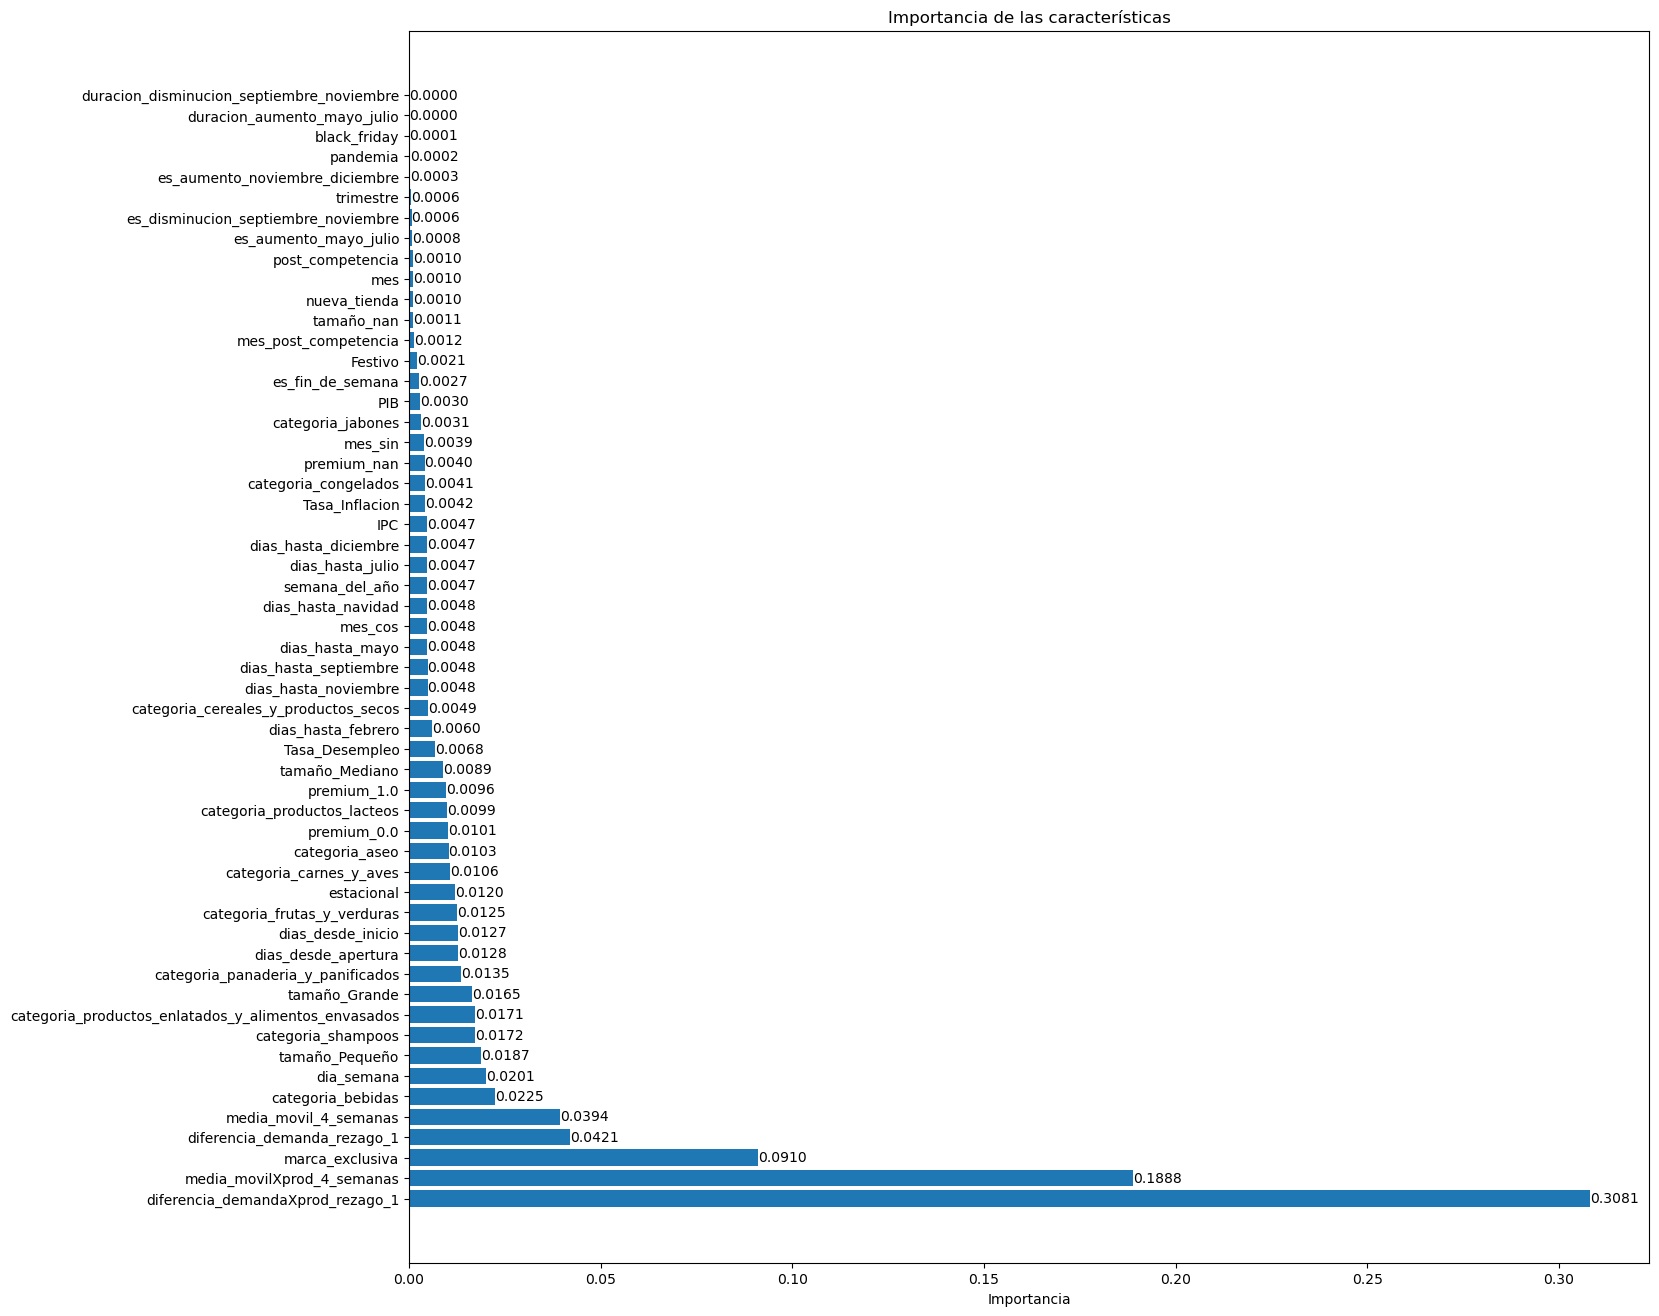

In [67]:
importancia_caracteristicas = pipeline_rf.named_steps['rf_classifier'].feature_importances_

importancia_df = pd.DataFrame({
    'Característica': X_train.columns,
    'Importancia': importancia_caracteristicas
})

# Ordenar el dataframe por la importancia
importancia_df = importancia_df.sort_values(by='Importancia', ascending=False)

# Graficar la importancia de las características
plt.figure(figsize=(16,18))
bars = plt.barh(importancia_df['Característica'], importancia_df['Importancia'])

# Añadir los valores de la importancia sobre las barras
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.4f}', 
             va='center', ha='left', color='black', fontsize=10)

plt.xlabel('Importancia')
plt.title('Importancia de las características')
plt.show()

Tras analizar la importancia de las características del modelo, hemos observado que las variables ``black_friday``, ``duracion_disminucion_septiembre_noviembre`` y ``duracion_aumento_mayo_julio`` tienen una contribución mínima al rendimiento del modelo, con valores de importancia notablemente bajos.

Dado que estas variables no están aportando significativamente a la capacidad predictiva del modelo, se ha decidido proceder con su eliminación para optimizar el rendimiento del modelo. Al reducir la dimensionalidad del modelo, se espera mejorar la eficiencia del entrenamiento y evitar el sobreajuste al eliminar características que podrían estar generando ruido sin contribuir a la precisión de las predicciones.

Con esta eliminación, continuaremos trabajando con las características más relevantes y ajustaremos los hiperparámetros del modelo para maximizar su desempeño.

In [27]:
X_train2 = X_train.drop(columns=['black_friday','duracion_disminucion_septiembre_noviembre','duracion_aumento_mayo_julio']) 
X_test2 = X_test.drop(columns=['black_friday','duracion_disminucion_septiembre_noviembre','duracion_aumento_mayo_julio'])

In [71]:
# Definir el pipeline con el modelo RandomForestRegressor
pipeline_rf2 = Pipeline([
    ("scalar3", StandardScaler()),
    ("rf_classifier", RandomForestRegressor(random_state=42))
])

# Definir los parámetros a ajustar (hiperparámetros del RandomForestRegressor)
param_grid = {
    'rf_classifier__n_estimators': [100, 200],  # Número de árboles en el bosque
    'rf_classifier__max_depth': [None, 10, 20, 30],   # Profundidad máxima de los árboles
    'rf_classifier__min_samples_split': [2, 5],    # Mínimo número de muestras para dividir un nodo
    'rf_classifier__min_samples_leaf': [1, 2],      # Mínimo número de muestras por hoja
    'rf_classifier__max_features': ['auto', 'sqrt'],  # Características a considerar en cada división
    'rf_classifier__bootstrap': [True]          # Si se debe usar bootstrap (muestreo con reemplazo)
}

# Inicializar el GridSearchCV con el pipeline y los parámetros
grid_search = GridSearchCV(
    estimator=pipeline_rf2, 
    param_grid=param_grid, 
    cv=5,                  # Validación cruzada de 5 pliegues
    n_jobs=4,             # Usar todos los núcleos disponibles
    verbose=2,             # Mostrar progreso
    scoring='neg_root_mean_squared_error'  # Para regresión, usando RMSE
)

# Ajustar el modelo con el conjunto de entrenamiento
grid_search.fit(X_train2, y_train)

# Ver los mejores parámetros encontrados
print("Mejores parámetros:", grid_search.best_params_)

# Ver el mejor puntaje (RMSE negativo)
print("Mejor RMSE (negativo):", grid_search.best_score_)

# Obtener el mejor modelo
best_model = grid_search.best_estimator_

# Evaluar el modelo con el conjunto de prueba
y_pred2 = best_model.predict(X_test2)

# Calcular el RMSE en el conjunto de prueba
rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))
print(f"RMSE en conjunto de prueba: {rmse2:.2f}")

Fitting 5 folds for each of 64 candidates, totalling 320 fits


C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
160 fits failed out of a total of 320.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
71 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Javier\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 473, in fit
    self._final_estimat

Mejores parámetros: {'rf_classifier__bootstrap': True, 'rf_classifier__max_depth': 30, 'rf_classifier__max_features': 'sqrt', 'rf_classifier__min_samples_leaf': 1, 'rf_classifier__min_samples_split': 2, 'rf_classifier__n_estimators': 200}
Mejor RMSE (negativo): -124.55686960756168
RMSE en conjunto de prueba: 111.82


Tras realizar la optimización de los hiperparámetros, hemos observado que no hubo una mejora significativa en el valor de RMSE con los parámetros seleccionados. Esto indica que, aunque la optimización de hiperparámetros es un paso crucial, no es el único factor que impacta de manera significativa en el desempeño del modelo.

En consecuencia, se ha decidido explorar nuevas variables derivadas de la información obtenida a partir de la importancia de las características. Este enfoque tiene como objetivo enriquecer el modelo con nuevas variables que puedan capturar patrones adicionales no considerados previamente, lo que podría mejorar la capacidad predictiva del modelo y reducir el error de predicción.

Con esta estrategia, buscamos aprovechar al máximo los datos disponibles y refinar el modelo para lograr un rendimiento más preciso y robusto.

In [28]:
df_unida3['diferencia_demandaXprod_rezago_1'] = df_unida3['diferencia_demandaXprod_rezago_1'].replace(0, 1)

df_unida3['diffXprod_MV4S'] = df_unida3['diferencia_demandaXprod_rezago_1']/df_unida3['media_movil_4_semanas']
df_unida3['diff_MV4S'] = df_unida3['diferencia_demanda_rezago_1']/df_unida3['media_movil_4_semanas']
df_unida3['marca_diffXprod'] = df_unida3['marca_exclusiva']/df_unida3['diferencia_demandaXprod_rezago_1'] #
df_unida3['bebidas_diffXprod'] = df_unida3['categoria_bebidas']/df_unida3['diferencia_demandaXprod_rezago_1'] #
df_unida3['pequeño_diffXprod'] = df_unida3['tamaño_Pequeño']/df_unida3['diferencia_demandaXprod_rezago_1'] #
df_unida3['grande_diffXprod'] = df_unida3['tamaño_Grande']/df_unida3['diferencia_demandaXprod_rezago_1'] #
df_unida3['diasemana_diffXprod'] = df_unida3['dia_semana']/df_unida3['diferencia_demandaXprod_rezago_1'] #

ventas_diariasXprod2 = df_unida3.groupby(['date', 'id_producto'])['demanda'].sum().reset_index()
ventas_diariasXprod2['media_movilXprod_8_semanas'] = ventas_diariasXprod2['demanda'].rolling(window=56, min_periods=1).mean()
ventas_diariasXprod2['media_movilXprod_12_semanas'] = ventas_diariasXprod2['demanda'].rolling(window=84, min_periods=1).mean()
df_unida3 = df_unida3.merge(ventas_diariasXprod2[['date', 'id_producto',
                                               'media_movilXprod_8_semanas',
                                               'media_movilXprod_12_semanas']], on=['date', 'id_producto'], how='left')

df_train2 = df_unida3[df_unida3['date'] <= '2021-12-31']
df_test2 = df_unida3[df_unida3['date'] > '2021-12-31']

X_train3 = df_train2.drop(columns=['demanda', 'date','id_producto','subcategoria','nit_proveedor',
                                   'mes_year','black_friday','duracion_disminucion_septiembre_noviembre','duracion_aumento_mayo_julio']) 
y_train3 = df_train2['demanda']

X_test3 = df_test2.drop(columns=['demanda', 'date','id_producto','subcategoria','nit_proveedor',
                                 'mes_year','black_friday','duracion_disminucion_septiembre_noviembre','duracion_aumento_mayo_julio'])
y_test3 = df_test2['demanda']

In [29]:
pipeline_rf3 = Pipeline([
    ("scalar3", StandardScaler()),
    ("rf_classifier", RandomForestRegressor(
        n_estimators=200,
        max_depth=30,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        bootstrap=True,
        random_state=42
    ))
])

# Entrenar el modelo
pipeline_rf3.fit(X_train3, y_train3)

# Obtener las predicciones
y_pred3 = pipeline_rf3.predict(X_test3)

# Calcular el RMSE en el conjunto de prueba
rmse3 = np.sqrt(mean_squared_error(y_test3, y_pred3))
print(f"RMSE: {rmse3:.2f}")

RMSE: 111.13


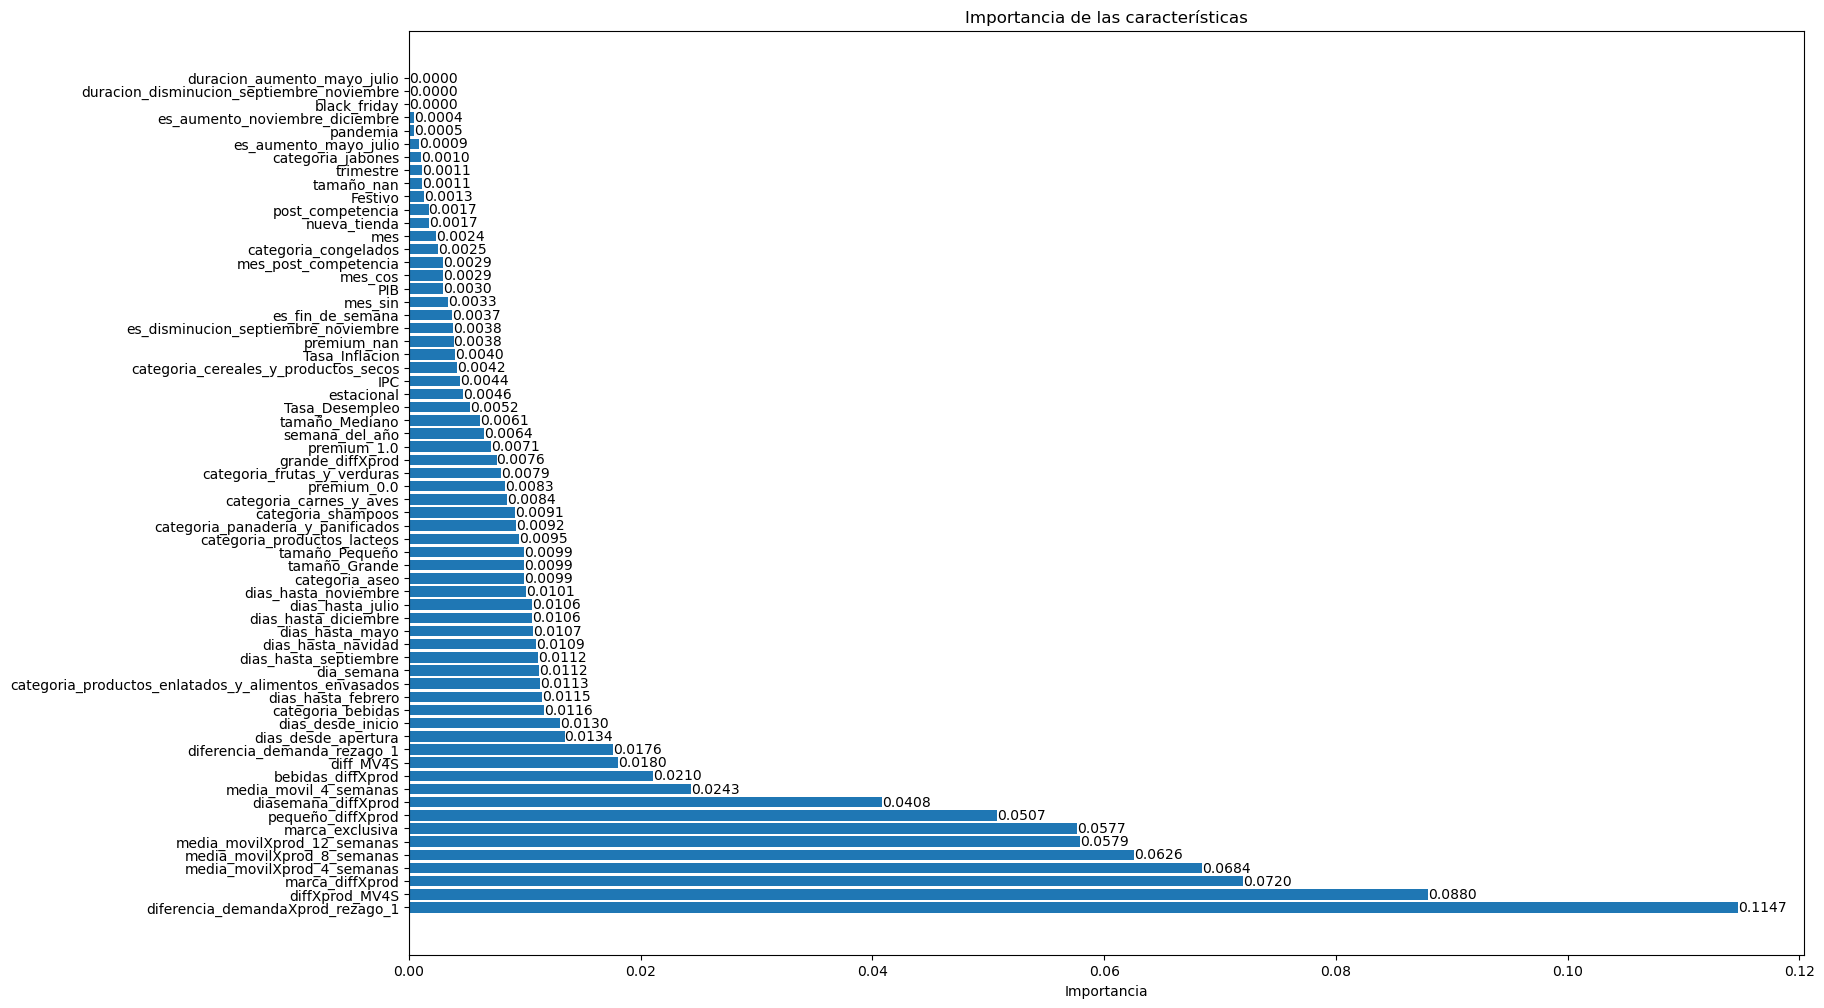

In [47]:
importancia_caracteristicas2 = pipeline_rf3.named_steps['rf_classifier'].feature_importances_

importancia_df2 = pd.DataFrame({
    'Característica': X_train3.columns,
    'Importancia': importancia_caracteristicas2
})

# Ordenar el dataframe por la importancia
importancia_df2 = importancia_df2.sort_values(by='Importancia', ascending=False)

# Graficar la importancia de las características
plt.figure(figsize=(18, 12))
bars = plt.barh(importancia_df2['Característica'], importancia_df2['Importancia'])

# Añadir los valores de la importancia sobre las barras
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.4f}', 
             va='center', ha='left', color='black', fontsize=10)

plt.xlabel('Importancia')
plt.title('Importancia de las características')
plt.show()

Se ha logrado una ligera reducción en el RMSE del modelo RandomForest, por lo que ahora se procederá a realizar un análisis de los residuos con el fin de identificar posibles áreas de mejora y seguir optimizando el modelo para obtener mejores resultados.

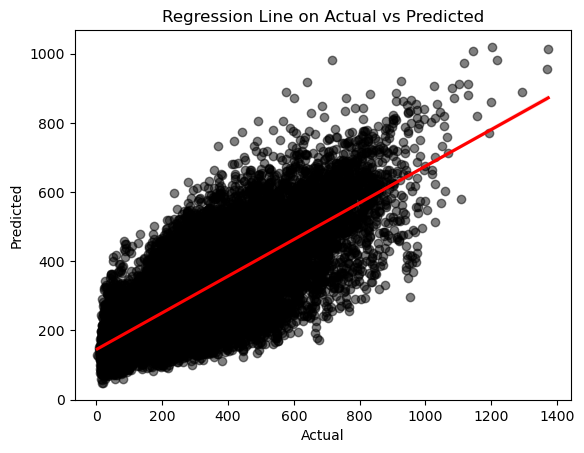

In [82]:
df_results = pd.DataFrame({
    'Actual': y_test3,
    'Predicted': y_pred3,
    'residuos': y_test3-y_pred3
})

sns.regplot(x='Actual', y='Predicted', data=df_results,
            scatter_kws = {"color": "black", "alpha": 0.5},
            line_kws = {"color": "red"},
            ci = 99) # Intervalo al 99%
plt.title('Regression Line on Actual vs Predicted')
plt.show()

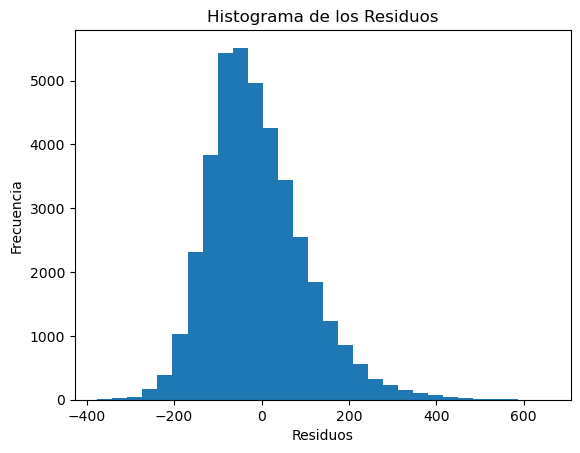

In [84]:
plt.hist(df_results['residuos'], bins=30)
plt.title('Histograma de los Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.show()

El histograma de los residuos está sesgado hacia valores negativos, esto indica que el modelo tiende a sobreestimar las predicciones en comparación con los valores reales. Es decir, en promedio, el modelo está haciendo predicciones más altas que los valores observados, y los residuos

In [36]:
pipeline_xgb=Pipeline([("scalar3",StandardScaler()),
                     ("xgb_classifier",XGBRegressor())])

pipeline_xgb.fit(X_train3, y_train3)

y_pred_xgb = pipeline_xgb.predict(X_test3)

rmse_xgb = np.sqrt(mean_squared_error(y_test3, y_pred3))
print(f"RMSE: {rmse_xgb:.2f}")

RMSE: 111.13


In [38]:
param_grid = {
    'xgb_classifier__learning_rate': [0.01, 0.1, 0.2],
    'xgb_classifier__max_depth': [3, 5, 7],
    'xgb_classifier__n_estimators': [100, 200, 300],
    'xgb_classifier__subsample': [0.8, 0.9, 1.0],
    'xgb_classifier__colsample_bytree': [0.8, 0.9, 1.0]
}

grid_search = GridSearchCV(pipeline_xgb, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train3, y_train3)

best_params_xgb = grid_search.best_params_
print(f"Mejores hiperparámetros: {best_params_xgb}")

# Usar el mejor modelo
pipeline_xgb2 = grid_search.best_estimator_
y_pred_xgb2 = pipeline_xgb2.predict(X_test3)

rmse_xgb2 = np.sqrt(mean_squared_error(y_test3, y_pred_xgb2))
print(f"RMSE: {rmse_xgb2:.2f}")

C:\Users\Javier\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Mejores hiperparámetros: {'xgb_classifier__colsample_bytree': 0.9, 'xgb_classifier__learning_rate': 0.1, 'xgb_classifier__max_depth': 7, 'xgb_classifier__n_estimators': 300, 'xgb_classifier__subsample': 0.9}
RMSE: 100.95


### Ensamble Modelos
Se procederá a realizar los siguientes ensambles para el Random Forest y XGBoost con el objetivo de evaluar si se mejora el RMSE:
- Promediar las predicciones de ambos modelos (XGBoost y Random Forest) para obtener una predicción final.
- Asignar pesos a cada modelo según su rendimiento.
- Utilizar la técnica de **stacking**, que consiste en entrenar un meta-modelo (por ejemplo, una regresión lineal) para combinar las predicciones de XGBoost y Random Forest de manera más sofisticada.
- Emplear la clase **VotingRegressor** de Scikit-learn, que permite combinar fácilmente varios modelos, como XGBoost y Random Forest, para obtener una predicción conjunta.

In [40]:
# Predicciones de XGBoost
y_pred_xgb = pipeline_xgb2.predict(X_test3)

# Predicciones de Random Forest
y_pred_rf = pipeline_rf3.predict(X_test3)

# Promedio de las predicciones
y_pred_avg = (y_pred_xgb + y_pred_rf) / 2

# Calcular RMSE del ensamblado
rmse_avg = np.sqrt(mean_squared_error(y_test3, y_pred_avg))
print(f"RMSE del ensamblado (promedio): {rmse_avg:.2f}")

RMSE del ensamblado (promedio): 102.66


In [42]:
# Pesos basados en el rendimiento (ajusta según tus necesidades)
weight_xgb = 0.55  # Más peso a XGBoost
weight_rf = 0.45   # Menos peso a Random Forest

# Predicciones ponderadas
y_pred_weighted = (weight_xgb * y_pred_xgb) + (weight_rf * y_pred_rf)

# Calcular RMSE del ensamblado ponderado
rmse_weighted = np.sqrt(mean_squared_error(y_test3, y_pred_weighted))
print(f"RMSE del ensamblado ponderado: {rmse_weighted:.2f}")

RMSE del ensamblado ponderado: 102.17


In [48]:
from sklearn.model_selection import cross_val_predict

# Crear un nuevo conjunto de datos con las predicciones de ambos modelos
X_train_stack = np.column_stack((pipeline_xgb2.predict(X_train3), pipeline_rf3.predict(X_train3)))

# Entrenar un meta-modelo (por ejemplo, una regresión lineal)
meta_model = LinearRegression()
meta_model.fit(X_train_stack, y_train3)

# Predecir en el conjunto de prueba
X_test_stack = np.column_stack((pipeline_xgb2.predict(X_test3), pipeline_rf3.predict(X_test3)))
y_pred_stack = meta_model.predict(X_test_stack)

# Calcular RMSE del ensamblado (stacking)
rmse_stack = np.sqrt(mean_squared_error(y_test3, y_pred_stack))
print(f"RMSE del ensamblado (stacking): {rmse_stack:.2f}")

RMSE del ensamblado (stacking): 123.09


In [50]:
from sklearn.ensemble import VotingRegressor

# Crear el ensamblado
ensemble = VotingRegressor([
    ('xgb', pipeline_xgb2.named_steps['xgb_classifier']),
    ('rf', pipeline_rf3.named_steps['rf_classifier'])
])

# Entrenar el ensamblado
ensemble.fit(X_train3, y_train3)

# Predecir en el conjunto de prueba
y_pred_ensemble = ensemble.predict(X_test3)

# Calcular RMSE del ensamblado
rmse_ensemble = np.sqrt(mean_squared_error(y_test3, y_pred_ensemble))
print(f"RMSE del ensamblado (VotingRegressor): {rmse_ensemble:.2f}")

RMSE del ensamblado (VotingRegressor): 103.36


In [52]:
# Predicciones de Random Forest
y_pred_rf = pipeline_rf3.predict(X_train3)

# Residuos de Random Forest
residuals = y_train3 - y_pred_rf

# Entrenar XGBoost sobre los residuos
pipeline_xgb2.fit(X_train3, residuals)

# Predicciones finales
y_pred_rf_test = pipeline_rf3.predict(X_test3)
y_pred_xgb_residuals = pipeline_xgb2.predict(X_test3)
y_pred_boosted = y_pred_rf_test + y_pred_xgb_residuals

# Calcular RMSE del ensamblado (boosting)
rmse_boosted = np.sqrt(mean_squared_error(y_test3, y_pred_boosted))
print(f"RMSE del ensamblado (boosting): {rmse_boosted:.2f}")

RMSE del ensamblado (boosting): 104.64


### Conclusión y Consideraciones



1. El mejor ensamblado fue el promedio ponderado (102.17):

- Esta técnica es simple pero efectiva, especialmente cuando un modelo (en este caso, XGBoost) tiene un rendimiento significativamente mejor que el otro, por lo que se recomendaria usar esta técnica como enfoque principal, ya que es fácil de implementar y dio los mejores resultados.

2. El promedio simple también es una buena opción (102.66):

- Si no se quiere ajustar pesos, el promedio simple es una alternativa sólida y casi igual de efectiva.

3. Stacking no funcionó bien en este caso (123.09):

- El stacking puede ser una técnica poderosa, pero requiere un ajuste cuidadoso del meta-modelo y los hiperparámetros. En este caso, no fue la mejor opción, se puede probar stacking nuevamente, considera usar un meta-modelo más robusto (por ejemplo, Ridge Regression o Lasso) y ajustar sus hiperparámetros.

4. VotingRegressor y Boosting son opciones viables:

- Ambas técnicas dieron resultados decentes, pero no superaron al promedio ponderado. Si  se busca simplicidad, VotingRegressor es una buena opción, tambien se puede explorar técnicas más avanzadas, el boosting puede valer la pena, aunque en este caso no fue el mejor.

5. XGBoost es el modelo más fuerte:

- El hecho de que el promedio ponderado (con más peso a XGBoost) diera el mejor resultado confirma que XGBoost es el modelo más robusto en este problema.